Método das diferenças finitas linear:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

In [2]:
def p(x):
    return 0

def q(x):
    return 4

def r(x):
    return -4*x

def real_f(x):
    return math.e**2 * (math.e**4 - 1)**-1 * (np.exp(2*x) - np.exp(-2*x)) + x

In [3]:
def diferencas_finitas(ti,tf,h,alpha,beta,p,q,r):
    N = int(np.round((tf - ti)/h))
    t = np.linspace(ti,tf,N + 1)
    n_sistema = (N + 1) - 2

    y = np.zeros(N + 1)
    a = np.zeros(n_sistema)
    b = np.zeros(n_sistema)
    d = np.zeros(n_sistema)
    c = np.zeros(n_sistema)

    a[0] = 2 + (h**2) * q(t[1])
    b[0] = -1 + (h/2)* p(t[1])
    d[0] = -(h**2)*r(t[1]) + (1 + (h/2)*p(t[1]))*alpha

    for i in range(1, n_sistema):
        a[i] = 2 + (h**2)*q(t[i + 1])
        b[i] = -1 + (h/2)*p(t[i + 1])
        c[i] = -1 - (h/2)*p(t[i + 1])
        d[i] = -(h**2)*r(t[i + 1])

    a[n_sistema - 1] = 2 + (h**2)*q(t[N - 1])
    c[n_sistema - 1] = -1 -(h / 2)*p(t[N - 1])
    d[n_sistema - 1] = -(h**2)*r(t[N - 1]) + (1 - (h/2)*p(t[N - 1]))*beta

    l = np.zeros(n_sistema)
    u = np.zeros(n_sistema)
    z = np.zeros(n_sistema)

    #Algorítmo de Thomas
    l[0] = a[0]
    u[0] = b[0]/a[0]
    z[0] = d[0]/l[0]

    for i in range(1, n_sistema):
        l[i] = a[i] - c[i] * u[i-1]
        if i < n_sistema - 1:
            u[i] = b[i] / l[i]
        z[i] = (d[i] - c[i] * z[i-1]) / l[i]

    l[n_sistema - 1] = a[n_sistema - 1] - c[n_sistema - 1]*u[n_sistema - 2]
    z[n_sistema - 1] = (d[n_sistema - 1] - c[n_sistema - 1]*z[n_sistema - 2])/l[n_sistema - 1]

    y[0] = alpha
    y[N] = beta
    y[N - 1] = z[n_sistema - 1]

    for i in range(n_sistema - 2, -1, -1):
        y[i + 1] = z[i] - u[i]*y[i + 2]


    return t,y

In [4]:
t_1,y_1= diferencas_finitas(0,1,0.25,0,2,p,q,r)
t_2,y_2= diferencas_finitas(0,1,0.5,0,2,p,q,r)

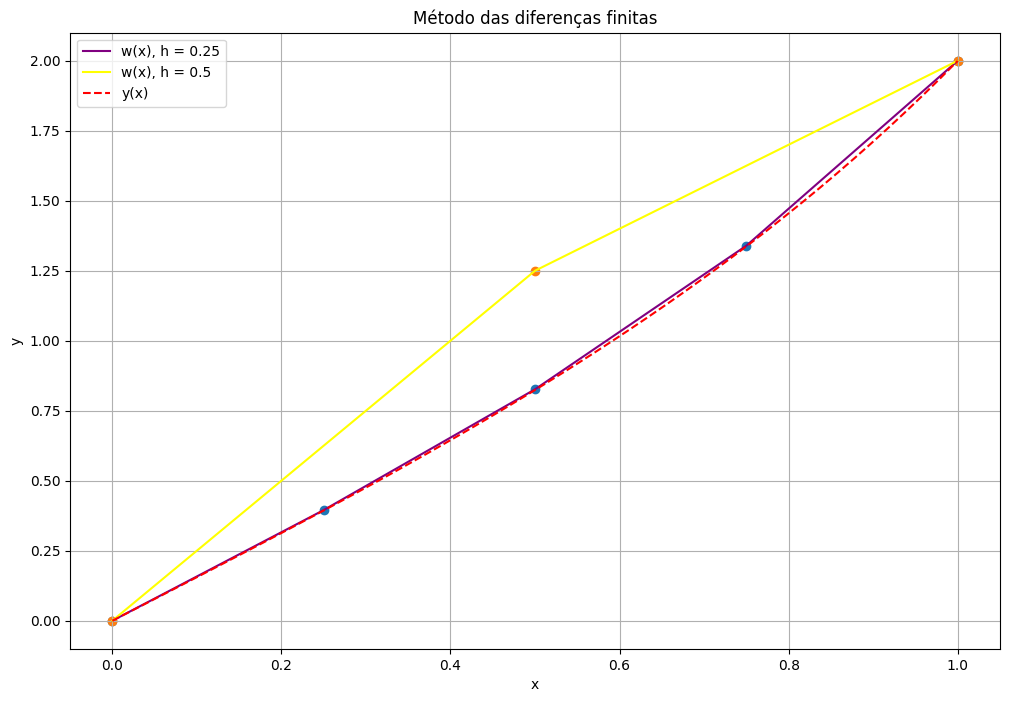

In [8]:
t_real = np.linspace(0,1)
plt.figure(figsize=(12,8))
plt.plot(t_1,y_1, label = f"w(x), h = {0.25}", color = '#800080')
plt.plot(t_2,y_2, label = f"w(x), h = {0.5}", color = 'yellow')
plt.scatter(t_1,y_1)
plt.scatter(t_2,y_2)
plt.plot(t_real, real_f(t_real), linestyle = '--', color = 'red', label = "y(x)")
plt.legend()
plt.title("Método das diferenças finitas")
plt.ylabel("y")
plt.xlabel("x")
plt.grid()
plt.show()